#### Sampling + IK in `Cabinet` environment

In [1]:
from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.qt import *
# trajectory tools 
from ri_motion_v5_package.traj_optimization.traj_utils import *
from ri_motion_v5_package.traj_optimization.traj_shaper import *
# gp tools 
from ri_motion_v5_package.gaussian_process.gp_utils import *
from ri_motion_v5_package.gaussian_process.kernels import rbf_kernel

from package.panda_env import * 

from PyQt5.QtWidgets import QApplication
app = QApplication(sys.argv)

Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.


In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files = [
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/cabinet/cabinet_half_closed.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_cabinet_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [4] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/cabinet/cabinet_half_closed.xml]
  - [3] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_cabinet_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[28]
 [0/28] [world] parent:[world] mass:[0.00]kg
 [1/28] [panda_base] parent:[world] mass:[0.00]kg
 [2/28] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/28] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/28] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/28] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/28] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/28] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/28] [panda_link_6] parent:[panda_link_5] mass:[1.50]

#### 1. Initialize environment and prepare sampling

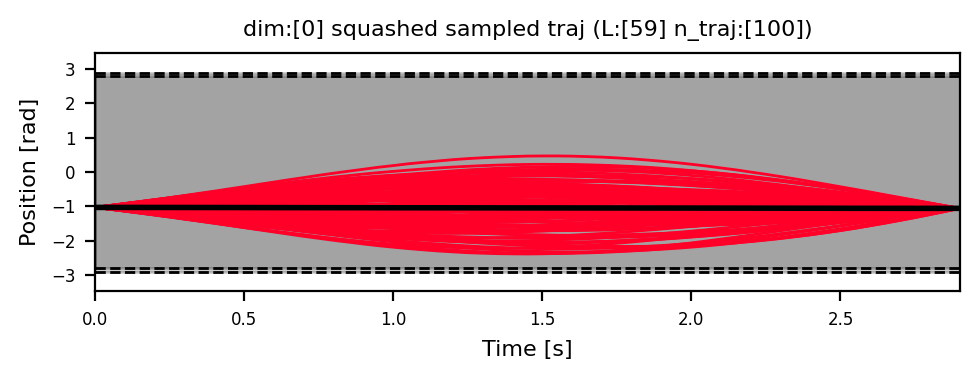

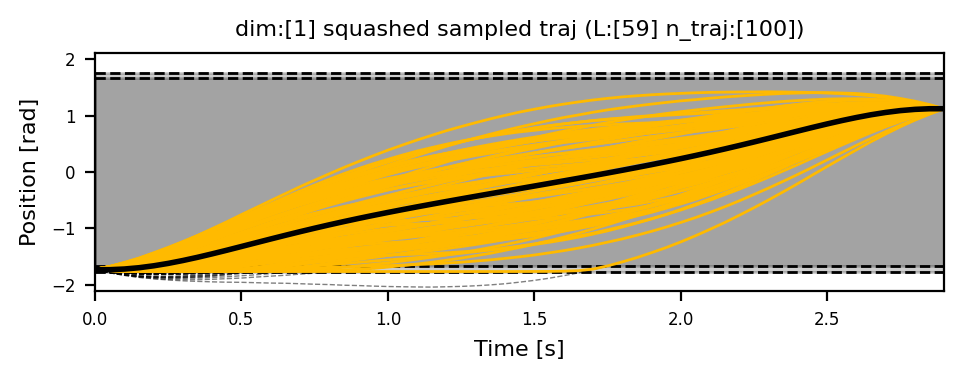

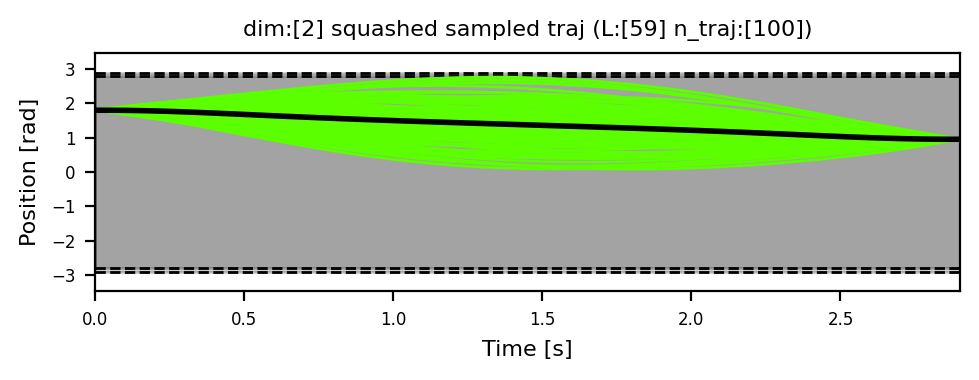

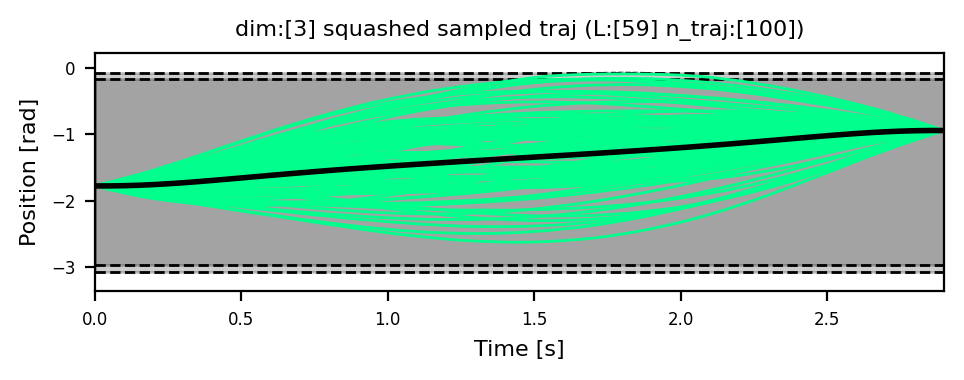

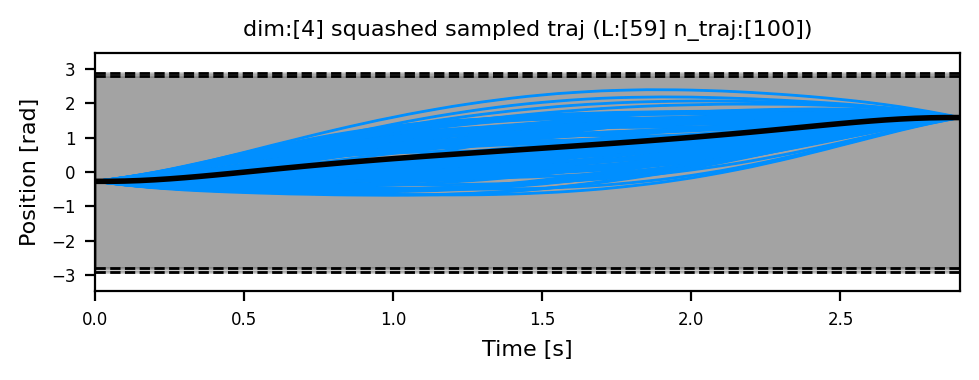

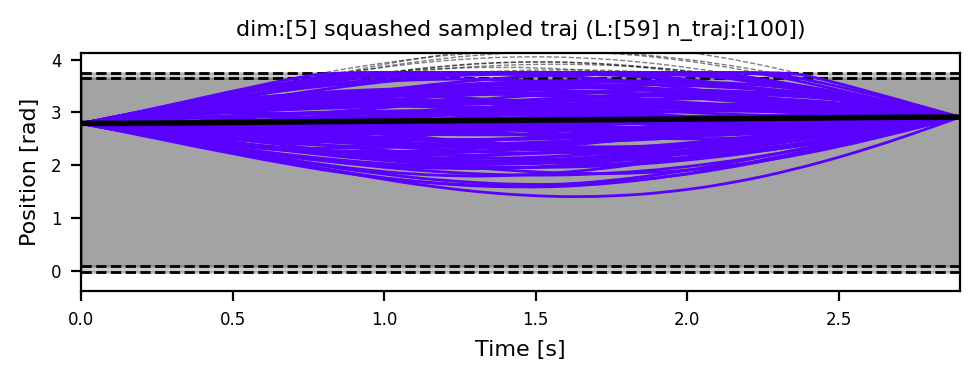

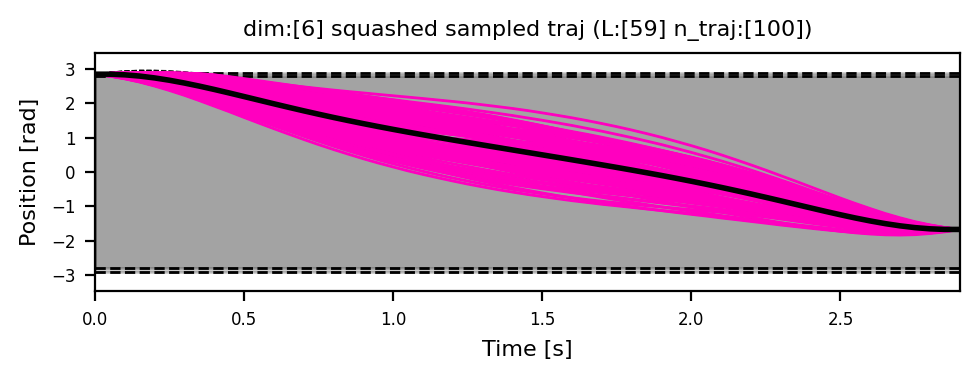

In [3]:
# Configurations
panda_joints          = get_panda_joint_names()
inspire_joints        = get_inspire_joint_names()
inspire_active_joints = env.get_active_among_joints(inspire_joints)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
qactive_inspire0      = get_qactive_inspire()
q_inspire0            = get_q_inspire(env)
q_pandas              = get_q_pandas_cabinet()

# Compute piecewise linear trajectories from init to final
anchors = np.vstack((q_pandas['init'],q_pandas['final'])) # (M x dim)
n_anchor,dim = anchors.shape[0],anchors.shape[1]
res = get_interp_const_vel_traj_nd(
    anchors = anchors, # (M x dim)
    vel     = 90*D2R, # maximum velocity
    Hz      = 20,
)
times        = res['times_interp'] # (L)
trajs_lin    = res['anchors_interp'] # (L x dim)
times_anchor = res['times_anchor'] # (M,)
idxs_anchor  = res['idxs_anchor'] # (M,)
L,t_max = times.shape[0],times[1]

# Smooth joint trajectory
trajs_smt = np.zeros_like(trajs_lin) # (L x dim)
for d_idx in range(dim):
    res = traj_1d_shaper(
        t        = times, # (L,)
        x_ref    = trajs_lin[:,d_idx], # (L)
        idxs_eq  = idxs_anchor, # (M,)
        vals_eq  = anchors[:,d_idx], #(M,)
        v_init   = 0.0,
        v_final  = 0.0,
        lambda_j = 1e-4,
    )
    trajs_smt[:,d_idx] = res['z'] # (L,)

# Define (mean-zero) Hilbert space
t_max  = times[-1]
t_in   = np.array([0,t_max])
t_out  = np.linspace(0.0,t_max,L)
hyp    = {'length_scale':0.5*t_max,'variance':1.0}
K_chol = get_schur_K_chol(t_in,t_out,rbf_kernel,hyp)

# Sample from the mean-zero (ms) Hilbert space and mean shift (ms)
n_traj   = 100 # number of trajectories
trajs_list_mz = sample_trajs_multidim(
    K_chol      = K_chol,
    n_traj      = n_traj,
    d           = dim,
    use_uniform = True,
) # (L x n_traj x dim)
trajs_list_ms = trajs_list_mz + trajs_smt[:,None,:] # (L x n_traj x dim)

# Soft squash (sq)
x_mins = env.get_joint_mins(panda_joints)
x_maxs = env.get_joint_maxs(panda_joints)
m      = 0.1 # soft squash margin
trajs_list_sq = soft_squash_multidim(
    trajs_list_ms,x_min=x_mins,x_max=x_maxs,margin=m,dim_axis=2,
) # (L x n_traj x dim)

# Plot sampled trajctories
colors = get_colors(n_color=dim,cmap_name='gist_rainbow')
for d_idx in range(dim): # for each dim
    plt.figure(figsize=(5,2))
    traj_ms  = trajs_list_ms[:,:,d_idx] # (L,n_traj)
    traj_sq  = trajs_list_sq[:,:,d_idx] # (L,n_traj)
    traj_smt = trajs_smt[:,d_idx]  # (L,)
    rgba     = colors[d_idx]
    plt.fill_between(t_out,x_mins[d_idx],x_maxs[d_idx],color='k',alpha=0.2)
    plt.fill_between(t_out,x_mins[d_idx]+m,x_maxs[d_idx]-m,color='k',alpha=0.2)
    plt.plot(t_out,np.full_like(t_out,x_mins[d_idx]+m),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_maxs[d_idx]-m),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_mins[d_idx]),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_maxs[d_idx]),'--',lw=1.0,color='k')
    plt.plot(t_out,traj_ms,'--',color='k',lw=0.5,alpha=0.5)
    plt.plot(t_out,traj_sq,'-',color=rgba,lw=1.0,alpha=1.0)
    plt.plot(t_out,traj_smt,'-',color='k',lw=2.0,alpha=1.0)
    plt.xlabel('Time [s]',fontsize=8); plt.ylabel('Position [rad]',fontsize=8);
    plt.xlim([0.0,t_out[-1]])
    plt.ylim([x_mins[d_idx]-0.1*(x_maxs[d_idx]-x_mins[d_idx]),
              x_maxs[d_idx]+0.1*(x_maxs[d_idx]-x_mins[d_idx])])
    plt.title("dim:[%d] squashed sampled traj (L:[%d] n_traj:[%d])"%
              (d_idx,L,n_traj),fontsize=8)
    plt.tight_layout(); plt.show()

#### 2. Warm-up sampling and select the best one

In [4]:
# Initialize env and viewer
set_panda_cabinet_env(env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0, initialize_viewer=False)

# Sample from the mean-zero (ms) Hilbert space and mean shift (ms)
seed     = 0 # random seed 0~4
n_traj   = 500 # number of trajectories
trajs_list_mz = sample_trajs_multidim(
    K_chol      = K_chol,
    n_traj      = n_traj,
    d           = dim,
    use_uniform = True,
    seed        = seed,
) # (L x n_traj x dim)
trajs_list_ms = trajs_list_mz + trajs_smt[:,None,:] # (L x n_traj x dim)
print ("Sample [%d] trajectories and select the best one..."%(n_traj))

# Soft squash (sq)
x_mins = env.get_joint_mins(panda_joints)
x_maxs = env.get_joint_maxs(panda_joints)
m      = 0.1 # soft squash margin
trajs_list_sq = soft_squash_multidim(
    trajs_list_ms,x_min=x_mins,x_max=x_maxs,margin=m,dim_axis=2,
) # (L x n_traj x dim)

# Loop over sampled trajectories and compute the cost
env.tt.tic()
scores = np.zeros(n_traj) # (n_traj,)
for traj_idx in range(n_traj): # for each trajectory
    traj_sq = trajs_list_sq[:,traj_idx,:] # (L x dim)
    _scores = np.zeros(L)
    for tick in range(L): # for each tick
        q = traj_sq[tick,:] # (dim)
        env.forward(q=q,joint_names=panda_joints) # fk panda
        T_palm = get_T_palm_panda_inspire(env)
        p_cylinder_offset = p_cylinder_offset0
        T_cylinder = view_in_world(T=p2t(p_cylinder_offset),T_wl=T_palm)
        env.set_T('body_cylinder','base_body',T_cylinder)
        # Get contact info
        contact_info = env.get_contact_info() # contact info
        n_contact = contact_info['n_contact'] # number of contact
        min_contact_dist = contact_info['min_contact_dist'] # np.inf or negative
        # Compute instantaneous score
        if min_contact_dist > 0: score = 0.0
        else: score = n_contact*min_contact_dist
        # Append the instantaneous score
        _scores[tick] = score
    # Append minimum (worst case) score (per trajectory)
    scores[traj_idx] = _scores.min()
esec = env.tt.toc()
# Get the maximum score index
idx_best   = int(np.argmax(scores))
score_best = scores[idx_best]
trajs_warmup  = trajs_list_sq[:,idx_best,:] # (L x dim)
print("idx_best:[%d] score_best:[%e] trajs_warmup:%s esec:[%.3f]sec"%
      (idx_best,score_best,trajs_warmup.shape,esec))
# Close
env.close_viewer()
print ("Done.")

Sample [500] trajectories and select the best one...
idx_best:[77] score_best:[-4.081687e-01] trajs_warmup:(59, 7) esec:[19.875]sec
Done.


#### 3. Animate the initial interpolated trajectory (`trajs_smt`)

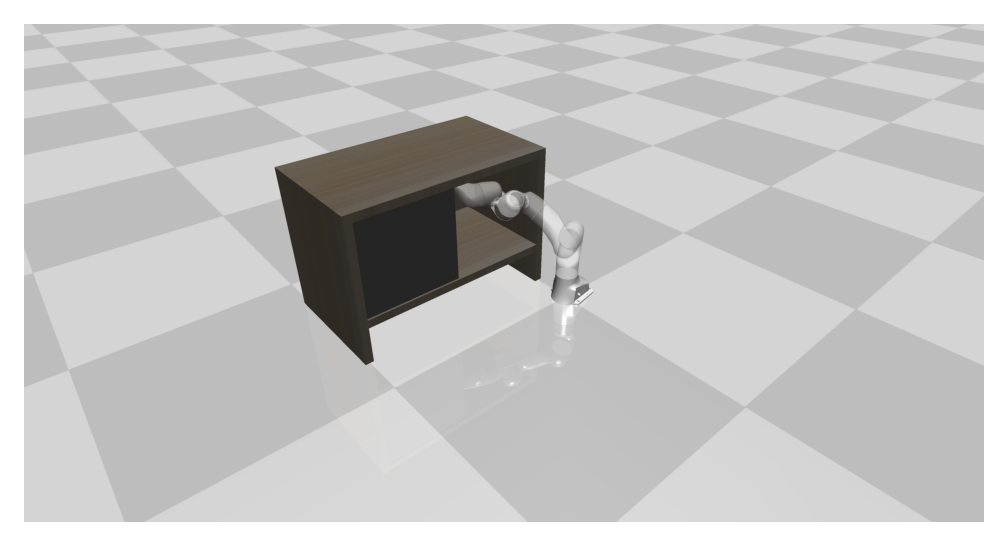

Done.


In [5]:
animate_init_interp_result = True
if animate_init_interp_result:
    mode_str = "Initial interpolation result"
    animate_cabinet_env_traj(
        env                = env,
        mode_str           = mode_str,
        traj               = trajs_smt,
        panda_joints       = panda_joints,
        inspire_joints     = inspire_joints,
        q_pandas           = q_pandas,
        q_inspire0         = q_inspire0,
        p_cylinder_offset0 = p_cylinder_offset0,
        app                 = app,
        ubuntu_process_events_flag=True,
    )
    imshow(env.final_rgb_img)
print ("Done.")

#### 4. Animate the warm-up trajectory (`trajs_warmup`)

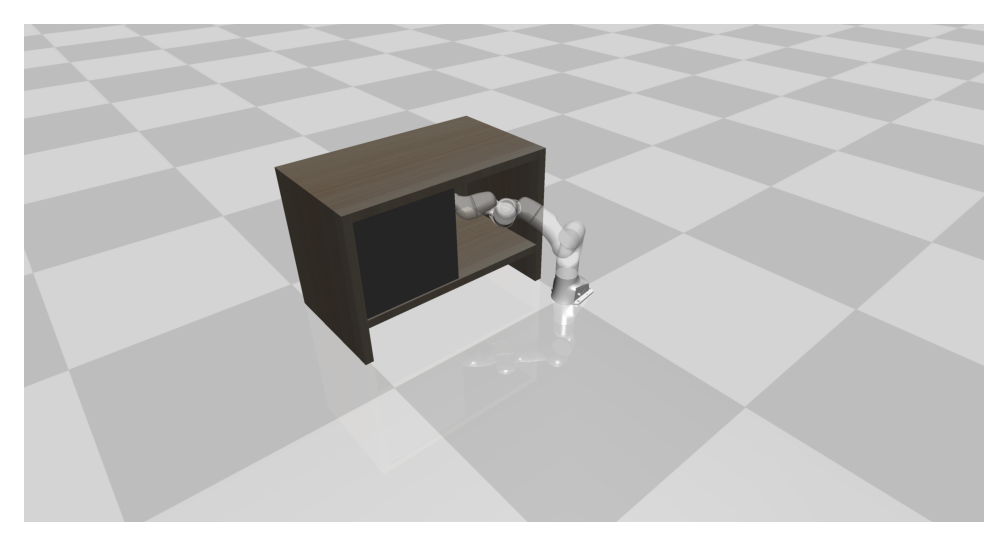

Done.


In [6]:
animate_grp_sampling_result = True
if animate_grp_sampling_result:
    mode_str = "Current best sampled result"
    animate_cabinet_env_traj(
        env                = env,
        mode_str           = mode_str,
        traj               = trajs_warmup,
        panda_joints       = panda_joints,
        inspire_joints     = inspire_joints,
        q_pandas           = q_pandas,
        q_inspire0         = q_inspire0,
        p_cylinder_offset0 = p_cylinder_offset0,
        app                 = app,
        ubuntu_process_events_flag=True,
    )
    imshow(env.final_rgb_img)
print ("Done.")

#### 5. Collision-handling of `trajs_warmup` to get `trajs_warmup_ch`
- `trajs_warmup` => `trajs_warmup_ch`

In [7]:
# Get robot and environment geom indices

geom_idxs_robot = env.get_geom_idxs_from_root_body_name(
    root_body_name  = 'panda_base',
    more_body_names = ['body_cylinder'],
)
geom_idxs_env = env.get_geom_idxs_from_root_body_name(
    root_body_name  = 'body_cabinet_half_closed',
)
body_idxs_robot = env.get_body_idxs_from_root_body_name(
    root_body_name  = 'panda_base',
)

# Initialize cabinet environment
width,height,x_offset,y_offset = 0.8,0.8,0.1,0.15
set_panda_cabinet_env(
    env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0,
    width,height,x_offset,y_offset, # initialize_viewer=False,
)

# IK configuration
joints_use = panda_joints
n_use      = len(joints_use)
idxs_use   = env.get_idxs_jac(joint_names=joints_use)
S_use      = np.zeros((env.model.nv,n_use),dtype=np.float64)  # (nv x n_use)
S_use[idxs_use,np.arange(n_use)] = 1.0

# Loop
trajs_warmup_ch = np.zeros_like(trajs_warmup) # (L x dim)
env.tt.tic()
print ("Collision-handling of the initial warm-up treajectory. L:[%d]..."%(L))
for tick in range(L):
    q = trajs_warmup[tick,:] # (dim)
    env.forward(q=q,joint_names=panda_joints) # fk panda
    T_palm = get_T_palm_panda_inspire(env)
    p_cylinder_offset = p_cylinder_offset0
    T_cylinder = view_in_world(T=p2t(p_cylinder_offset),T_wl=T_palm)
    env.set_T('body_cylinder','base_body',T_cylinder)
    # Contact handling routine
    ik_tick,max_ik_tick = 0,100
    while True:
        ik_tick = ik_tick + 1
        if ik_tick > max_ik_tick: break
        # Get contact information
        contact_info = env.get_contact_info() # contact info
        # Accumulate contact solving infomration
        J_p_list,p_fr_list,p_to_list = [],[],[]
        for c_idx in range(contact_info['n_contact']):
            p_contact = contact_info['p_contact_list'][c_idx]
            norm_dir  = contact_info['norm_dir_list'][c_idx]
            geom1_idx = contact_info['geom1_idx_list'][c_idx]
            geom2_idx = contact_info['geom2_idx_list'][c_idx]
            body1_idx = contact_info['body1_idx_list'][c_idx]
            body2_idx = contact_info['body2_idx_list'][c_idx]
            dist = 0.02 # IK handling dist
            p1_to,p2_to = p_contact-dist*norm_dir,p_contact+dist*norm_dir
            # geom 1
            if geom1_idx in geom_idxs_robot:
                J_p1,J_R1 = np.zeros((3,env.model.nv)),np.zeros((3,env.model.nv))
                if body1_idx not in body_idxs_robot:
                    body1_idx = body_idxs_robot[-1]
                mujoco.mj_jac(env.model,env.data,J_p1,J_R1,p_contact,body1_idx)
                J_p_list.append(J_p1)
                p_fr_list.append(p_contact)
                p_to_list.append(p1_to)
            # geom2
            if geom2_idx in geom_idxs_robot:
                J_p2,J_R2 = np.zeros((3,env.model.nv)),np.zeros((3,env.model.nv))
                if body2_idx not in body_idxs_robot:
                    body2_idx = body_idxs_robot[-1]
                mujoco.mj_jac(env.model,env.data,J_p2,J_R2,p_contact,body2_idx)
                J_p_list.append(J_p2)
                p_fr_list.append(p_contact)
                p_to_list.append(p2_to)
        # Contact handling using IK when necessary
        M = len(J_p_list) # number of IK positional targets
        if M > 0:
            # Stack Jacobian matrices and error vectors
            J_p_stack   = np.vstack(J_p_list) # (3*M x nv)
            p_fr_stack  = np.hstack(p_fr_list) # (3*M,)
            p_to_stack  = np.hstack(p_to_list) # (3*M,)
            p_err_stack = p_to_stack - p_fr_stack # (3*M,)
            J_use   = J_p_stack @ S_use # (3*M x n_use)
            JTJ_use = J_use.T @ J_use # (n_use x n_use)
            eps = 1e-6
            Jsharp_use = np.linalg.solve(JTJ_use+eps*np.eye(n_use),J_use.T)
            # Solve IK (primary task only, no nullspace)
            ik_step    = 0.5
            dq_use     = Jsharp_use @ p_err_stack
            dq_use     = trim_scale(dq_use,th=np.deg2rad(20))
            q_use      = env.get_qpos(joint_names=joints_use)
            q_use      = q_use + ik_step*dq_use
            q_use_min  = env.joint_mins[get_idxs(env.joint_names,joints_use)]
            q_use_max  = env.joint_maxs[get_idxs(env.joint_names,joints_use)]
            q_use_clip = np.clip(q_use,q_use_min,q_use_max)
            env.forward(q=q_use_clip,joint_names=joints_use)
            # Set cylinder pose
            T_palm = get_T_palm_panda_inspire(env)
            p_cylinder_offset = p_cylinder_offset0
            T_cylinder = view_in_world(T=p2t(p_cylinder_offset),T_wl=T_palm)
            env.set_T('body_cylinder','base_body',T_cylinder)
        else:
            break
    # Append joint position
    trajs_warmup_ch[tick,:] = env.get_qpos(panda_joints)
esec = env.tt.toc()
print ("It took [%.3f]sec."%(esec))

# Close
env.close_viewer()
print ("Done.")

Collision-handling of the initial warm-up treajectory. L:[59]...
It took [0.542]sec.
Done.


#### 6. Animate the collision-handled warm-up trajectory (`trajs_warmup_ch`)

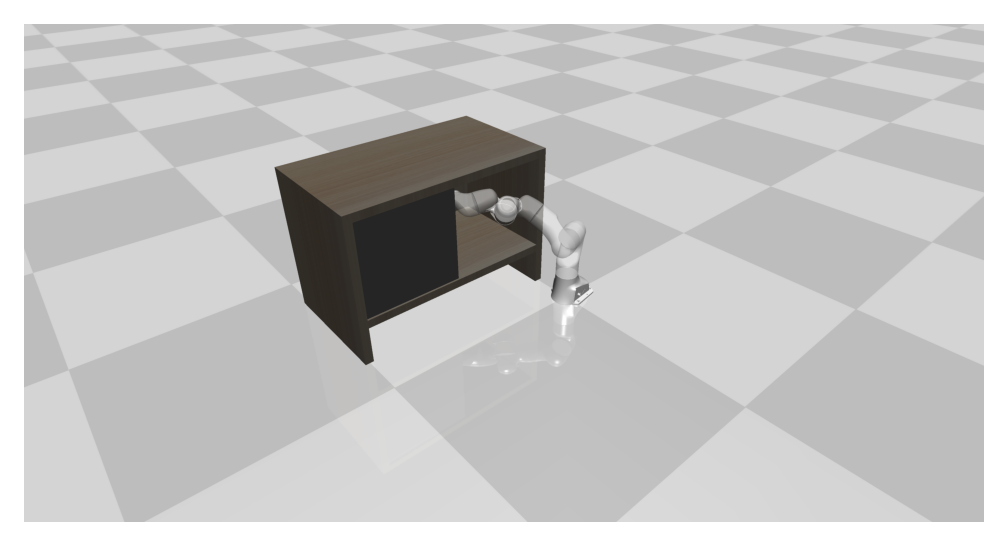

Done.


In [8]:
animate_grp_sampling_result = True
if animate_grp_sampling_result:
    mode_str = "Collision-handled of warm-up result"
    animate_cabinet_env_traj(
        env                = env,
        mode_str           = mode_str,
        traj               = trajs_warmup_ch,
        panda_joints       = panda_joints,
        inspire_joints     = inspire_joints,
        q_pandas           = q_pandas,
        q_inspire0         = q_inspire0,
        p_cylinder_offset0 = p_cylinder_offset0,
        app                 = app,
        ubuntu_process_events_flag=True,
    )
    imshow(env.final_rgb_img)
print ("Done.")

#### 7. Smooth the collision-handled warm-up trajectory to get `trajs_warmup_ch_smt`
- `trajs_warmup_ch` => `trajs_warmup_ch_smt`

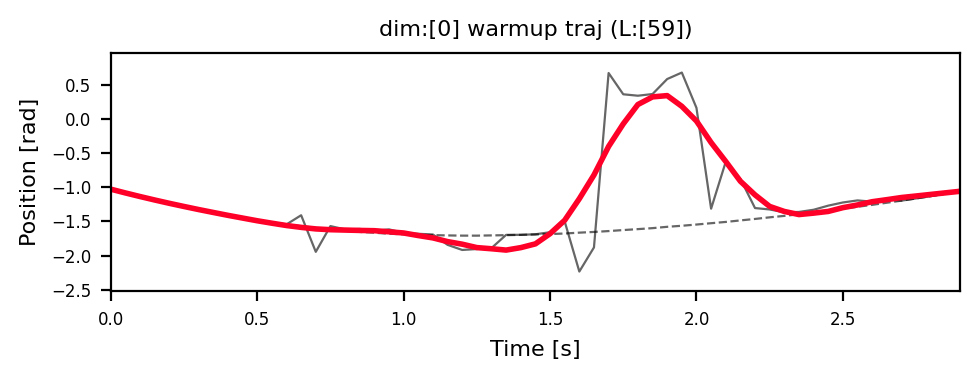

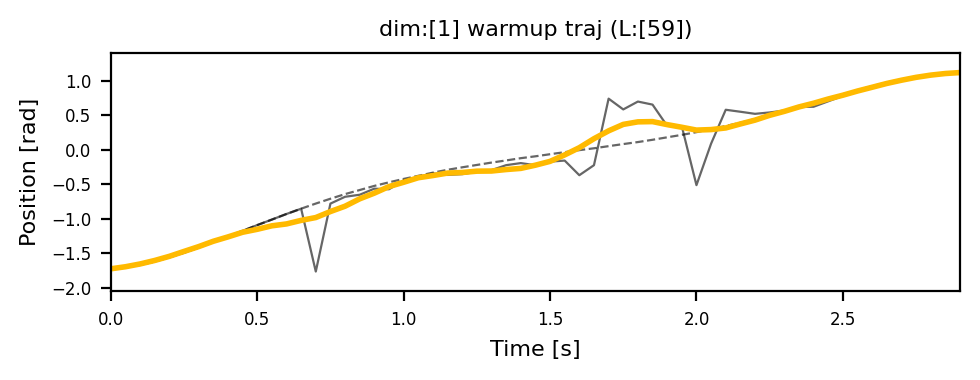

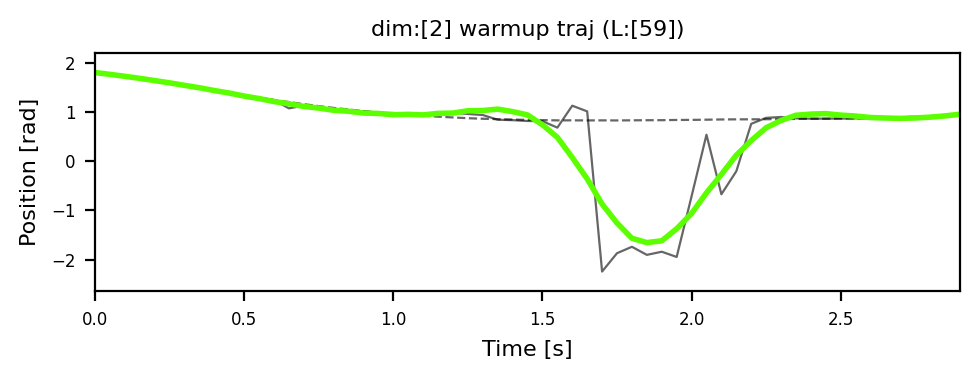

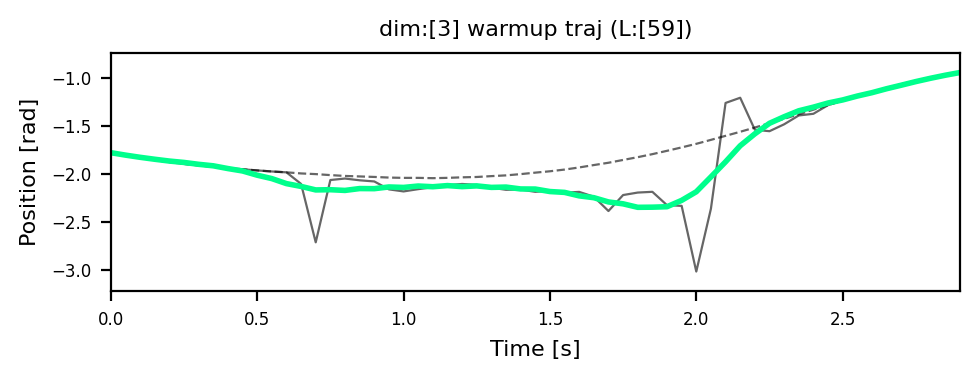

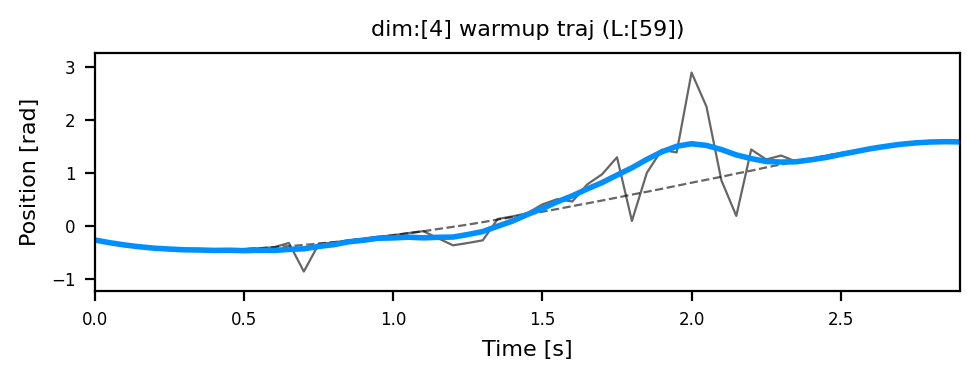

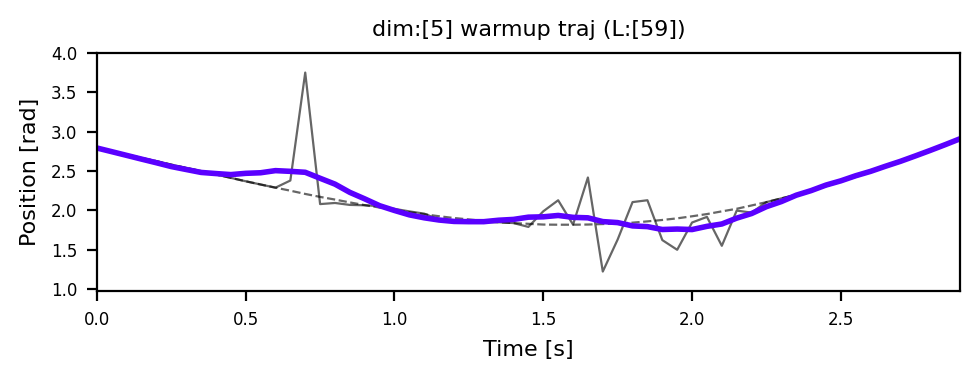

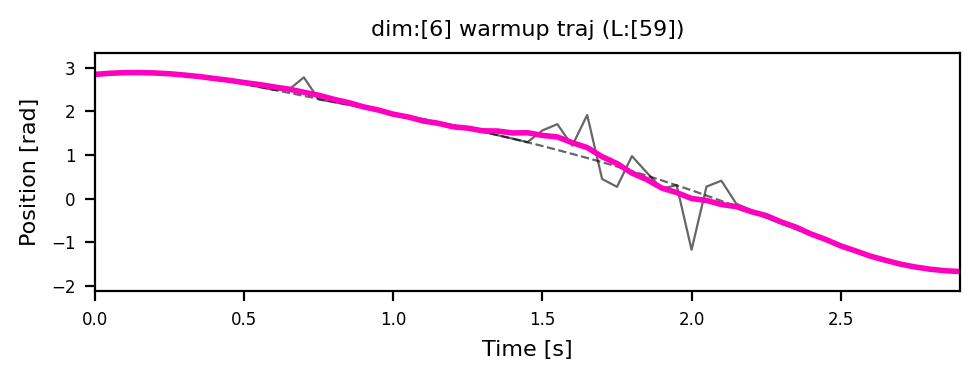

In [9]:
trajs_warmup_ch_smt = np.zeros_like(trajs_warmup_ch) # (L x dim)
for d_idx in range(dim):
    res = traj_1d_shaper(
        t        = times, # (L,)
        x_ref    = trajs_warmup_ch[:,d_idx], # (L)
        a_max    = 100,
        x_init   = trajs_warmup_ch[0,d_idx],
        x_final  = trajs_warmup_ch[-1,d_idx],
        lambda_j = 1e-6,
    )
    trajs_warmup_ch_smt[:,d_idx] = res['z'] # (L,)

# Plot warmup original vs smoothed, per-dim (style aligned with your reference)
colors = get_colors(n_color=dim,cmap_name='gist_rainbow')
for d_idx in range(dim):
    plt.figure(figsize=(5,2))
    traj_warmup = trajs_warmup[:,d_idx]
    traj_warmup_ch = trajs_warmup_ch[:,d_idx]
    traj_warmup_ch_smt = trajs_warmup_ch_smt[:,d_idx]
    plt.plot(t_out,traj_warmup,'--',color='k',lw=0.8,alpha=0.6)
    plt.plot(t_out,traj_warmup_ch,'-',color='k',lw=0.8,alpha=0.6)
    plt.plot(t_out,traj_warmup_ch_smt,'-',color=colors[d_idx],lw=2.0,alpha=1.0)
    plt.xlabel('Time [s]',fontsize=8); plt.ylabel('Position [rad]',fontsize=8)
    plt.xlim([t_out[0],t_out[-1]])
    ymin = min(np.min(traj_warmup_ch),np.min(traj_warmup_ch_smt))
    ymax = max(np.max(traj_warmup_ch),np.max(traj_warmup_ch_smt))
    pad  = 0.1*(ymax-ymin+1e-12)
    plt.ylim([ymin-pad,ymax+pad])
    plt.title("dim:[%d] warmup traj (L:[%d])"%(d_idx,L),fontsize=8)
    plt.tight_layout(); plt.show()

#### 8. Animate collision-handled smoothed trajectories (`trajs_warmup_ch_smt`)

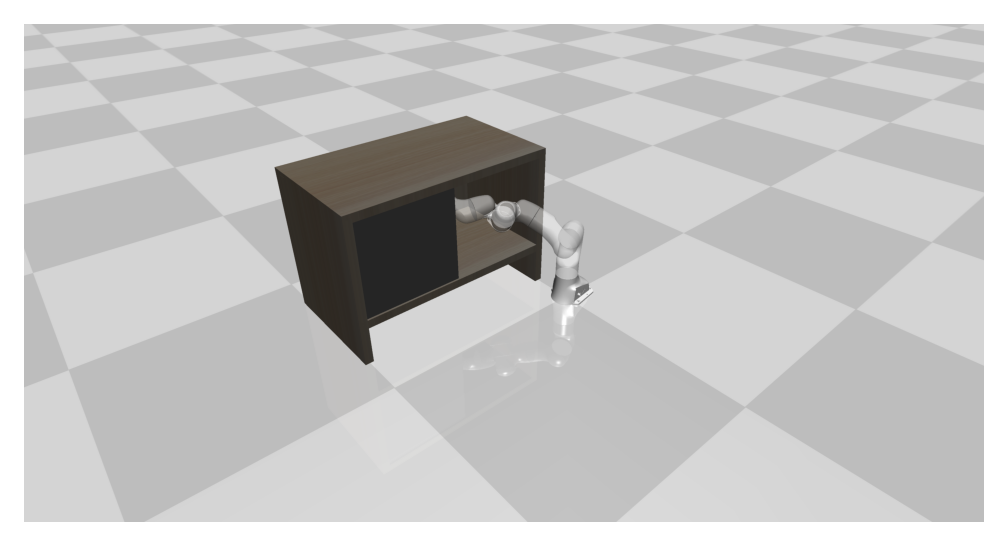

Done.


In [10]:
animate_ch_smt_result = True
if animate_ch_smt_result:
    mode_str = "Collision-handled smoothed result"
    animate_cabinet_env_traj(
        env                = env,
        mode_str           = mode_str,
        traj               = trajs_warmup_ch_smt,
        panda_joints       = panda_joints,
        inspire_joints     = inspire_joints,
        q_pandas           = q_pandas,
        q_inspire0         = q_inspire0,
        p_cylinder_offset0 = p_cylinder_offset0,
        app                 = app,
        ubuntu_process_events_flag=True,
    )
    imshow(env.final_rgb_img)
print ("Done.")

#### 9. Starting from `trajs_warmup_ch_smt` sample 
- `trajs_warmup_ch_smt` => `trajs_list_sq` => `trajs_argmax_grp`

In [11]:
# Define (mean-zero) Hilbert space (with small variance)
t_max  = times[-1]
t_in   = np.array([0,t_max])
t_out  = np.linspace(0.0,t_max,L)
# hyp    = {'length_scale':0.5*t_max,'variance':0.0}
hyp    = {'length_scale':0.5*t_max,'variance':0.0}
K_chol = get_schur_K_chol(t_in,t_out,rbf_kernel,hyp)

# Sample from the mean-zero (ms) Hilbert space and mean shift (ms)
n_traj = 500 # number of trajectories
trajs_list_mz = sample_trajs_multidim(
    K_chol      = K_chol,
    n_traj      = n_traj,
    d           = dim,
    use_uniform = True,
) # (L x n_traj x dim)
trajs_list_ms = trajs_list_mz + trajs_warmup_ch_smt[:,None,:] # (L x n_traj x dim)

# Soft squash (sq)
x_mins = env.get_joint_mins(panda_joints)
x_maxs = env.get_joint_maxs(panda_joints)
m      = 0.1 # soft squash margin
trajs_list_sq = soft_squash_multidim(
    trajs_list_ms,x_min=x_mins,x_max=x_maxs,margin=m,dim_axis=2,
) # (L x n_traj x dim)

# Loop over sampled trajectories and compute the cost
env.tt.tic()
scores = np.zeros(n_traj) # (n_traj,)
for traj_idx in range(n_traj): # for each trajectory
    traj_sq = trajs_list_sq[:,traj_idx,:] # (L x dim)
    _scores = np.zeros(L)
    for tick in range(L): # for each tick
        q = traj_sq[tick,:] # (dim)
        env.forward(q=q,joint_names=panda_joints) # fk panda
        T_palm = get_T_palm_panda_inspire(env)
        p_cylinder_offset = p_cylinder_offset0
        T_cylinder = view_in_world(T=p2t(p_cylinder_offset),T_wl=T_palm)
        env.set_T('body_cylinder','base_body',T_cylinder)
        # Get contact info
        contact_info = env.get_contact_info() # contact info
        n_contact = contact_info['n_contact'] # number of contact
        min_contact_dist = contact_info['min_contact_dist'] # np.inf or negative
        # Compute instantaneous score
        if min_contact_dist > 0: score = 0.0
        else: score = n_contact*min_contact_dist
        # Append the instantaneous score
        _scores[tick] = score
    # Append the average score (per trajectory)
    scores[traj_idx] = _scores.mean()
esec = env.tt.toc()
# Get the maximum score index
idx_best   = int(np.argmax(scores))
score_best = scores[idx_best]
trajs_argmax_grp = trajs_list_sq[:,idx_best,:] # (L x dim)
print("idx_best:[%d] score_best:[%e] trajs_argmax_grp:%s esec:[%.3f]sec"%
      (idx_best,score_best,trajs_argmax_grp.shape,esec))
# Close
env.close_viewer()
print ("Done.")

idx_best:[457] score_best:[-1.591444e-01] trajs_argmax_grp:(59, 7) esec:[19.653]sec
Done.


#### 10. Animate the best one (`trajs_argmax_grp`)

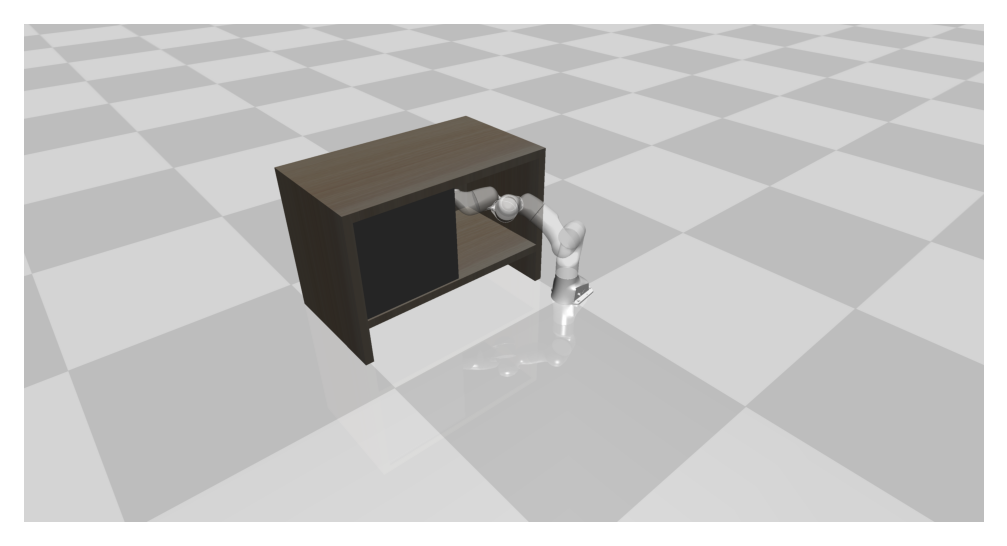

Done.


In [12]:
animate_argmax_grp_result = True
if animate_argmax_grp_result:
    mode_str = "Argmax GRP result"
    animate_cabinet_env_traj(
        env                = env,
        mode_str           = mode_str,
        traj               = trajs_argmax_grp,
        panda_joints       = panda_joints,
        inspire_joints     = inspire_joints,
        q_pandas           = q_pandas,
        q_inspire0         = q_inspire0,
        p_cylinder_offset0 = p_cylinder_offset0,
        app                 = app,
        ubuntu_process_events_flag=True,
    )
    imshow(env.final_rgb_img)
print ("Done.")